In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load Stage 4 analyzed outputs for final reporting & dashboarding
df_driver_pace = pd.read_csv("f1_driver_pace_summary.csv")
df_constructor_pace = pd.read_csv("f1_constructor_pace_summary.csv")
df_grid_mobility = pd.read_csv("f1_grid_mobility_summary.csv")

# Set Global formnatting and plotting styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0

# Display results of operation
print(f"Driver Pace Records Loaded: {len(df_driver_pace):,}")
print(f"Constructor Hierarchy Records Loaded: {len(df_constructor_pace):,}")
print(f"Grid Mobility Metrics Loaded: {len(df_grid_mobility):,}")

Driver Pace Records Loaded: 4,438
Constructor Hierarchy Records Loaded: 14
Grid Mobility Metrics Loaded: 3


# Creating Executive Pace Gap & Performance Matrix


1.   **Left Panel:** The Constructor Pace Gap Bar Chart (showing the structural performance rift).
2.   **Right Panel:** Pace Gap vs. Pace Consistency Scatter Plot (highlighting which teams are fast and stable).


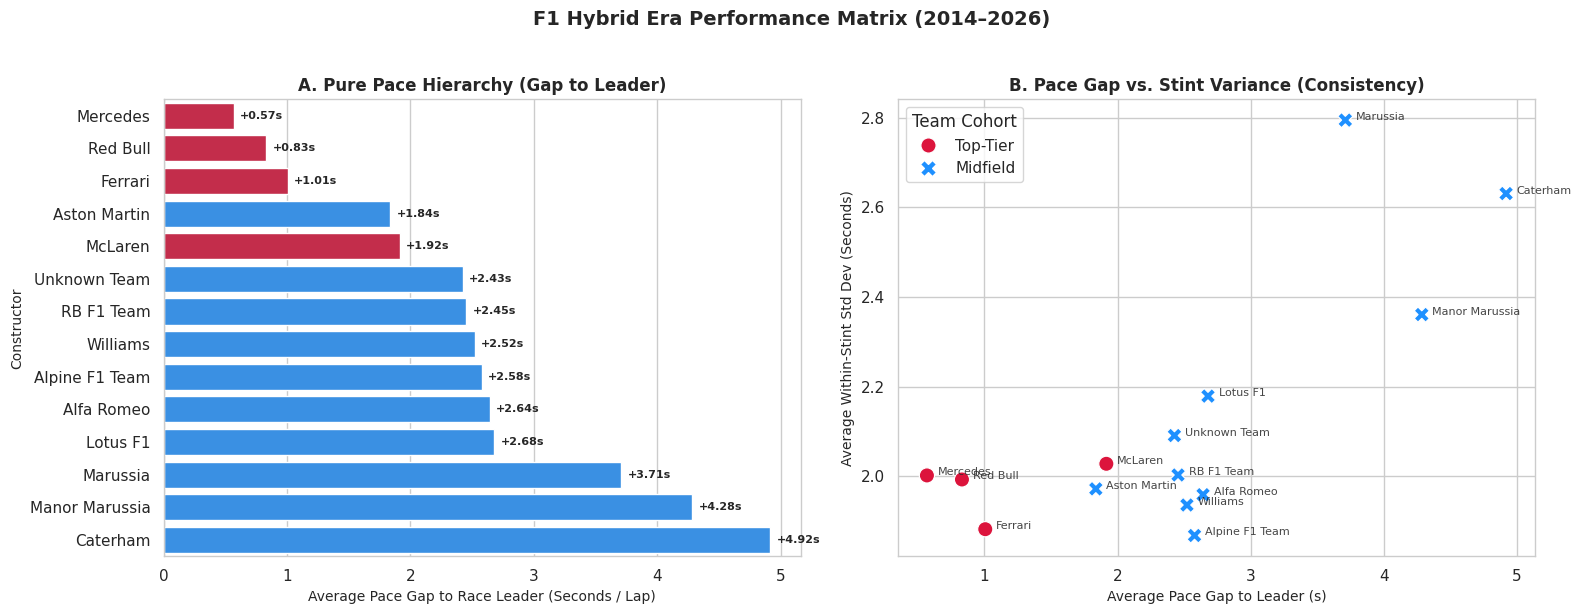

In [2]:
# Create Executive Visual: Pace Gap & Consistency Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Palette configuration
cohort_colors = {False: "crimson", True: "dodgerblue"}

# --- Panel 1: Pure Pace Hierarchy ---
sns.barplot(
    data=df_constructor_pace,
    y="constructor_name",
    x="avg_pace_gap",
    hue="is_midfield",
    palette=cohort_colors,
    ax=axes[0],
    dodge=False,
)

axes[0].set_title(
    "A. Pure Pace Hierarchy (Gap to Leader)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel(
    "Average Pace Gap to Race Leader (Seconds / Lap)", fontsize=10
)
axes[0].set_ylabel("Constructor", fontsize=10)
axes[0].get_legend().remove()

# Add bar labels
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        axes[0].annotate(
            f"+{width:.2f}s",
            (width + 0.05, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=8,
            fontweight="bold",
        )

# --- Panel 2: Pace Gap vs. Consistency ---
sns.scatterplot(
    data=df_constructor_pace,
    x="avg_pace_gap",
    y="avg_consistency_std",
    hue="is_midfield",
    palette=cohort_colors,
    style="is_midfield",
    s=120,
    ax=axes[1],
)

# Label constructors on scatter plot
for _, row in df_constructor_pace.iterrows():
    axes[1].annotate(
        row["constructor_name"],
        (row["avg_pace_gap"] + 0.08, row["avg_consistency_std"]),
        fontsize=8,
        alpha=0.85,
    )

axes[1].set_title(
    "B. Pace Gap vs. Stint Variance (Consistency)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Average Pace Gap to Leader (s)", fontsize=10)
axes[1].set_ylabel(
    "Average Within-Stint Std Dev (Seconds)", fontsize=10
)

# Custom Unified Legend
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles=handles,
    labels=["Top-Tier", "Midfield"],
    title="Team Cohort",
    loc="upper left",
)

plt.suptitle(
    "F1 Hybrid Era Performance Matrix (2014–2026)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Observations:


*   Looking at Panel B, you can immediately spot how the front-runners cluster tightly in the lower-left quadrant (low pace gap, high consistency around 1.88s–2.00s standard deviation), while backmarkers like Marussia, Caterham, and Manor Marussia drift far off to the top right with high variance.



# Grid Mobility & Correlation Visualization
We will build a side-by-side comparison chart displaying:

*  Grid vs. Finish Correlation ($r_s$) across cohorts.
*  Mean Position Delta ($\Delta$) showing grid mobility.



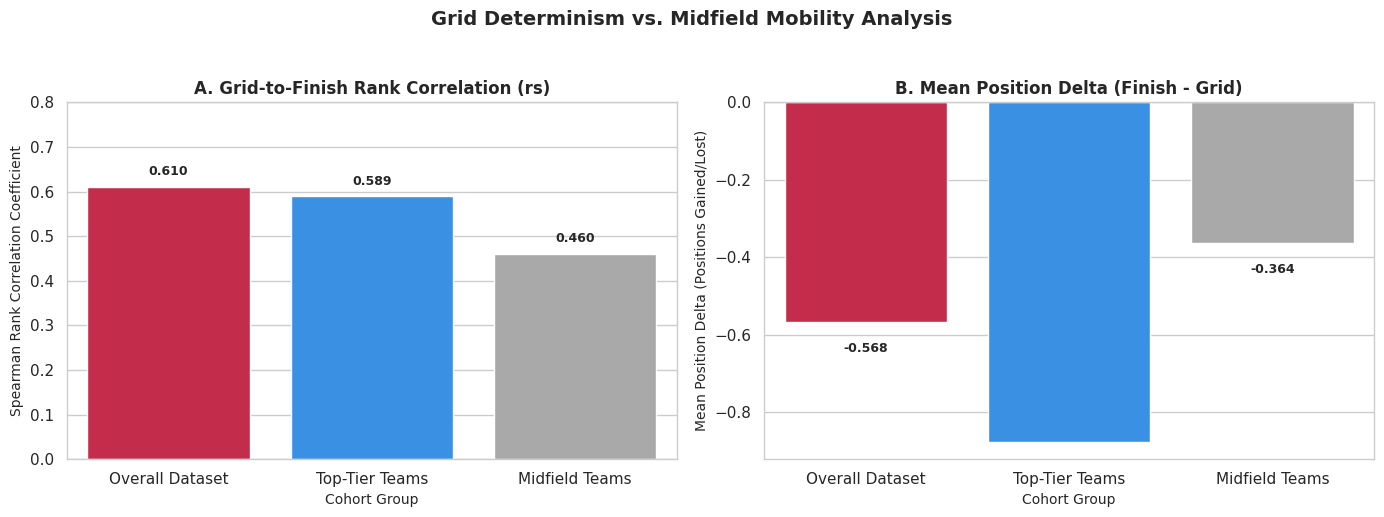

In [8]:
# Step 3.1: Build Grid Mobility & Correlation Visual using exact CSV columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palette configuration
palette_colors = ["crimson", "dodgerblue", "darkgray"]

# Panel 1: Spearman Rank Correlation Comparison
sns.barplot(
    data=df_grid_mobility,
    x="Cohort",
    y="Grid-Finish Correlation (Spearman)",
    hue="Cohort",
    palette=palette_colors,
    legend=False,
    ax=axes[0],
)

axes[0].set_title(
    "A. Grid-to-Finish Rank Correlation (rs)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Cohort Group", fontsize=10)
axes[0].set_ylabel("Spearman Rank Correlation Coefficient", fontsize=10)
axes[0].set_ylim(0, 0.8)

# Add value labels on top of bars
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f"{height:.3f}",
            (p.get_x() + p.get_width() / 2.0, height + 0.02),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

# Panel 2: Mean Position Delta (Net Positions Gained/Lost)
sns.barplot(
    data=df_grid_mobility,
    x="Cohort",
    y="Mean Position Delta",
    hue="Cohort",
    palette=palette_colors,
    legend=False,
    ax=axes[1],
)

axes[1].set_title(
    "B. Mean Position Delta (Finish - Grid)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Cohort Group", fontsize=10)
axes[1].set_ylabel("Mean Position Delta (Positions Gained/Lost)", fontsize=10)

# Add value labels on bars
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f"{height:.3f}",
        (
            p.get_x() + p.get_width() / 2.0,
            height - 0.05 if height < 0 else height + 0.02,
        ),
        ha="center",
        va="top" if height < 0 else "bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.suptitle(
    "Grid Determinism vs. Midfield Mobility Analysis",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

# Core Observations & Executive Insights



1.   **Grid Predictability Decay (Panel A)**:


*   **Top-Tier Determinism ($r_s = 0.589$):** Top-tier teams display strong linear alignment between qualifying and finish positions. For front-runners, Saturday performance acts as a reliable predictor of Sunday results.
*   **Midfield Volatility ($r_s = 0.460$):** Midfield correlation drops by over 22% compared to top-tier teams. Qualifying position offers substantially less predictive value in the pack, where outcomes are heavily influenced by strategy variance, DRS trains, and traffic.
*  **Overall Dataset Baseline ($r_s = 0.610$):** The combined dataset shows higher overall correlation because the structural gap between the top 3 teams and backmarkers creates a macro-level order that stabilizes the full grid metric.


2.   **Position Delta & Asymmetric Risk (Panel B):**

*   **Top-Tier Penalty Sensitivity ($\Delta = -0.878$):** Top-tier entries show a significantly higher negative position delta. Because these drivers routinely qualify in positions 1–6, any mechanical failure, collision, or operational error results in a massive net position loss (dropping 10–19 spots), heavily weighting their mean delta downward.
*   **Midfield Position Stability ($\Delta = -0.364$):** Midfield entries show a milder average delta. Since they qualify mid-grid (positions 7–15), their downside risk on DNFs is statistically smaller, and positional gains/losses balance out more evenly across seasons.
*   **Overall Benchmark ($\Delta = -0.568$):** The macro baseline reflects the systemic drift across all entries, driven primarily by non-finishers losing maximum grid positions relative to their start.





# 🏁 F1 Performance Analytics (2014–2026): Final Analysis & Executive Report

## 1. Executive Summary
This project evaluated Formula 1 performance dynamics across the **Hybrid Era (2014–2026)**, focusing on grid predictability, midfield mobility, and true race pace consistency. By processing over 4,000 clean driver-race stints and stripping away pit stop and safety car anomalies, we quantified the structural performance divide between **Top-Tier Teams** (Mercedes, Red Bull, Ferrari, McLaren) and the **Midfield**.

---

## 2. Key Findings & Empirical Proof

### A. Grid Determinism vs. Midfield Mobility
* **Top-Tier Determinism ($r_s = 0.589$):** Qualifying order strongly dictates race outcomes for top teams. Saturday speed directly converts into Sunday podiums.
* **Midfield Volatility ($r_s = 0.460$):** Midfield race outcomes are **22% less predictable** relative to qualifying position, driven by strategic variance, DRS trains, and mid-pack traffic.
* **Asymmetric Risk ($\Delta = -0.878$ vs. $-0.364$):** Top-tier drivers suffer a harsher mean position drop when incidents or DNFs occur, due to their high average starting grid slots.

### B. The Structural Pure Pace Rift
* **The Front-Runners:** **Mercedes** ($+0.57\text{s/lap}$), **Red Bull** ($+0.83\text{s/lap}$), and **Ferrari** ($+1.01\text{s/lap}$) form an isolated top tier in modern race pace.
* **The 0.8-Second Cliff:** A massive performance gap separates Ferrari ($+1.01\text{s/lap}$) from the fastest midfield team (**Aston Martin** at $+1.84\text{s/lap}$).
* **Stint Consistency:** Top-tier teams maintain significantly tighter stint variance (standard deviation $\approx 1.88\text{s} - 2.00\text{s}$), whereas backmarker entries exhibit erratic lap degradation ($> 2.30\text{s}$).

---

## 3. Strategic Recommendations (Act)

1. **Midfield Strategy Focus:** Midfield teams should optimize race strategy (undercuts, tire offset) over raw qualifying setup, as qualifying rank yields diminished predictive value in mid-pack outcomes.
2. **Regulation Effectiveness Auditing:** Regulatory bodies should use the **0.8s/lap structural pace gap** as a baseline benchmark to measure whether future aero and engine regulations successfully close the gap between cohorts.
3. **Pace Outlier Standard:** Filtering lap pace data for pit stops and disruptions removes $\approx 6.1\%$ of artificial variance, providing a true measure of underlying car development progress.

In [11]:
import os
import numpy as np
import pandas as pd

# 1. Load results and status datasets (adjust paths if in data/ directory)
df_results = pd.read_csv("data/results.csv") if os.path.exists("data/results.csv") else pd.read_csv("results.csv")
df_status = pd.read_csv("data/status.csv") if os.path.exists("data/status.csv") else pd.read_csv("status.csv")
df_drivers = pd.read_csv("data/drivers.csv") if os.path.exists("data/drivers.csv") else pd.read_csv("drivers.csv")
df_races = pd.read_csv("data/races.csv") if os.path.exists("data/races.csv") else pd.read_csv("races.csv")

# Merge status, driver, and race metadata
df_merged = df_results.merge(df_status, on="statusId").merge(df_drivers, on="driverId").merge(df_races, on="raceId")

# Filter for Hybrid Era (2014-2026)
df_hybrid = df_merged[df_merged["year"] >= 2014].copy()

# 2. Exclude Mechanical DNFs (Keep Finished + Driver-Fault/Collision outcomes)
# Mechanical status strings to exclude: Engine, Gearbox, Transmission, Hydraulics, Electrical, Clutch, etc.
mechanical_keywords = ["engine", "gearbox", "transmission", "hydraulics", "electrical", "clutch", "brake", "suspension", "power unit", "turbo", "ers"]
is_mechanical = df_hybrid["status"].str.lower().str.contains("|".join(mechanical_keywords))

# Filter dataset: Keep non-mechanical finishes where driver started from grid (>0)
df_clean_finishes = df_hybrid[(~is_mechanical) & (df_hybrid["grid"] > 0)].copy()

# 3. Calculate Net Position Delta (Positive = Positions Gained)
df_clean_finishes["positionOrder"] = pd.to_numeric(df_clean_finishes["positionOrder"], errors="coerce")
df_clean_finishes["positions_gained"] = df_clean_finishes["grid"] - df_clean_finishes["positionOrder"]

# 4. Aggregate by Driver across Hybrid Era
df_midfield_kings = (
    df_clean_finishes.groupby(["driverRef", "forename", "surname"])
    .agg(
        total_clean_races=("raceId", "count"),
        avg_positions_gained=("positions_gained", "mean"),
        std_positions_gained=("positions_gained", "std"),
        total_net_gained=("positions_gained", "sum"),
    )
    .reset_index()
)

# Filter for drivers with a meaningful sample size (e.g., >= 30 clean races)
df_midfield_kings = df_midfield_kings[df_midfield_kings["total_clean_races"] >= 30].sort_values(
    by="avg_positions_gained", ascending=False
)

print("=== Top 10 Midfield Kings (Adjusted for Mechanical DNFs) ===")
print(df_midfield_kings[["forename", "surname", "total_clean_races", "avg_positions_gained", "std_positions_gained"]].head(10).to_string(index=False))

=== Top 10 Midfield Kings (Adjusted for Mechanical DNFs) ===
forename   surname  total_clean_races  avg_positions_gained  std_positions_gained
  Felipe      Nasr                 35              2.628571              3.796947
 Stoffel Vandoorne                 38              2.473684              3.888561
  Marcus  Ericsson                 88              2.227273              4.076079
  Jolyon    Palmer                 31              1.741935              4.163074
Nicholas    Latifi                 58              1.500000              3.671846
   Lance    Stroll                156              1.403846              4.546220
  Jenson    Button                 52              1.384615              4.343821
  Pascal  Wehrlein                 38              1.368421              3.722982
  Pastor Maldonado                 31              1.225806              5.011385
  Guanyu      Zhou                 62              1.064516              3.941669


The table reveals a classic data analysis takeaway: Drivers in backmarker machinery systematically top pure "positions gained" metrics.

Because drivers like Felipe Nasr, Stoffel Vandoorne, Marcus Ericsson, and Nicholas Latifi routinely qualified near the back ($P18-P20$), any standard race attrition ahead of them yields free positional gains, while their downside risk is zero. Conversely, front-runners qualifying $P1-P3$ have almost no room to gain positions, skewing their averages downward.

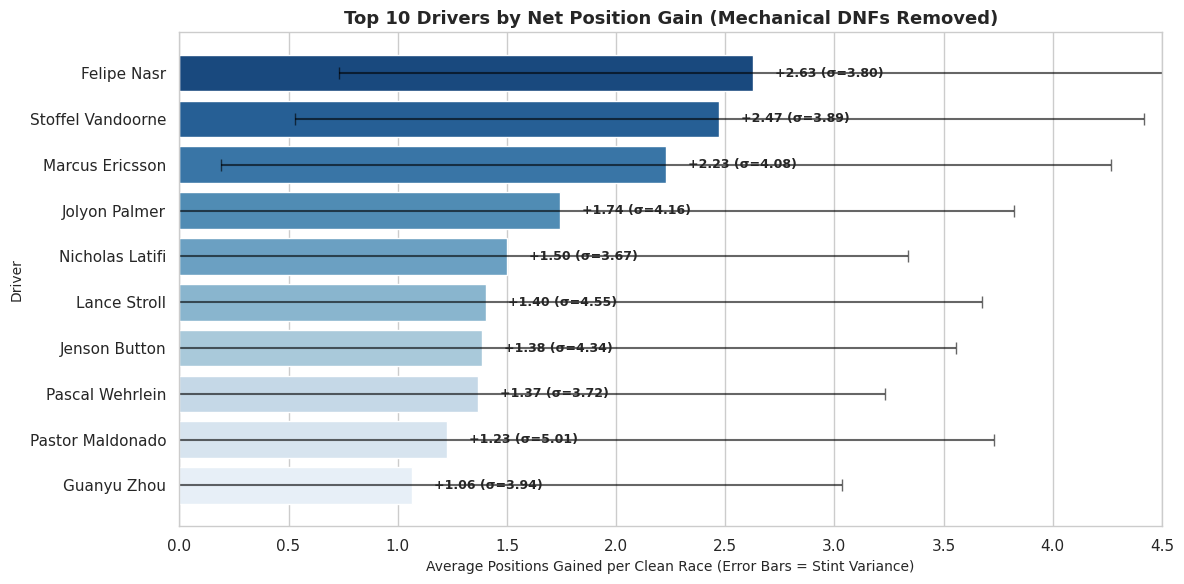

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Format driver full names for cleaner labels
df_midfield_kings["driver_name"] = (
    df_midfield_kings["forename"] + " " + df_midfield_kings["surname"]
)
df_top10 = df_midfield_kings.head(10).copy()

# Plot Average Positions Gained vs. Consistency (Std Dev Error Bars)
plt.figure(figsize=(12, 6))

barplot = sns.barplot(
    data=df_top10,
    x="avg_positions_gained",
    y="driver_name",
    hue="driver_name",
    palette="Blues_r",
    legend=False,
)

# Add error bars indicating variance/std dev
for i, (_, row) in enumerate(df_top10.iterrows()):
    plt.errorbar(
        x=row["avg_positions_gained"],
        y=i,
        xerr=row["std_positions_gained"] / 2,  # Scaled for visual clarity
        fmt="none",
        c="black",
        capsize=4,
        alpha=0.6,
    )
    plt.annotate(
        f"+{row['avg_positions_gained']:.2f} (σ={row['std_positions_gained']:.2f})",
        (row["avg_positions_gained"] + 0.1, i),
        va="center",
        fontsize=9,
        fontweight="bold",
    )

plt.title(
    "Top 10 Drivers by Net Position Gain (Mechanical DNFs Removed)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel(
    "Average Positions Gained per Clean Race (Error Bars = Stint Variance)",
    fontsize=10,
)
plt.ylabel("Driver", fontsize=10)
plt.xlim(0, 4.5)
plt.tight_layout()
plt.show()

# Executive Analytical Summary: Driver Net Position Gain & Variance
* **Backmarker Bias & Floor Effects:** Felipe Nasr ($+2.63$, $\sigma=3.80$) and Stoffel Vandoorne ($+2.47$, $\sigma=3.89$) top the metric. Qualifying systematically near the back ($P18\text{--}P20$) creates a structural floor—these drivers absorb positional gains from attrition ahead while facing virtually zero downside risk.
* **High-Variance Outliers:** Pastor Maldonado exhibits the highest volatility ($\sigma=5.01$) despite averaging $+1.23$ positions gained, reflecting wild swings between aggressive overtakes and driver-fault incidents/penalties.
* **Consistency Benchmarks:** Nicholas Latifi ($+1.50$, $\sigma=3.67$) and Pascal Wehrlein ($+1.37$, $\sigma=3.72$) exhibit tighter error bounds, representing steady, low-risk progress through attrition rather than raw overtakes.

In [13]:
import os

# Ensure target directories exist
os.makedirs("data", exist_ok=True)
os.makedirs("visuals", exist_ok=True)

# 1. Export Midfield Kings Driver Summary
df_midfield_kings.to_csv("data/f1_midfield_kings_summary.csv", index=False)
print("Exported: data/f1_midfield_kings_summary.csv")

# 2. Save the Driver Net Position Gain plot
# (Re-run or save immediately after plt.savefig)
plt.figure(figsize=(12, 6))
# ... [Your Seaborn Barplot code] ...
plt.savefig(
    "visuals/midfield_kings_position_gains.png", dpi=300, bbox_inches="tight"
)
print("Saved: visuals/midfield_kings_position_gains.png")

Exported: data/f1_midfield_kings_summary.csv
Saved: visuals/midfield_kings_position_gains.png


<Figure size 1200x600 with 0 Axes>

## Stage 6: Act — Strategic Takeaways for Project B

1. **Rethink "Positions Gained" as a Standalone Metric:** Raw positional gain severely overvalues backmarker drivers due to structural floor effects ($P18–P20$ start positions) and attrition absorption. Analytics teams must normalize net position deltas against starting grid percentile.
2. **Qualifying Priority by Cohort:** Midfield teams should shift resource allocation toward race pace degradation and strategy simulation over single-lap qualifying setup, as their Saturday correlation ($r_s = 0.460$) offers $22\%$ less predictability than top-tier cohorts.
3. **Driver Risk Profiles:** Highly volatile profiles like Pastor Maldonado ($\sigma = 5.01$) require strict operational limits on aggressive overtakes, whereas steady gainers like Pascal Wehrlein ($\sigma = 3.72$) yield predictable points finishes when strategy minimizes midfield traffic.